## 1. Data Ingestion & Preprocessing

In [ ]:
import pandas as pd
import torch
import pytorch_lightning as pl

# 1. Verify the GPU is now active
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

# 2. Load the dataset from Colab's session storage
file_path = "/content/caiso_engineered_features_2020_2024.csv"
df = pd.read_csv(file_path, index_col=0, parse_dates=True)

print(f"\nDataset loaded successfully!")
print(f"Total records: {len(df)}")
print(df[['Load', 'temperature_2m', 'is_holiday', 'rolling_max_7d']].head())

GPU Available: True
Device: Tesla T4

Dataset loaded successfully!
Total records: 43657
                                   Load  temperature_2m  is_holiday  \
2020-01-08 07:00:00+00:00  21887.083333             8.1           0   
2020-01-08 08:00:00+00:00  20721.083333             7.1           0   
2020-01-08 09:00:00+00:00  19941.833333             9.7           0   
2020-01-08 10:00:00+00:00  19512.250000            12.4           0   
2020-01-08 11:00:00+00:00  19424.250000            14.0           0   

                           rolling_max_7d  
2020-01-08 07:00:00+00:00    27936.333333  
2020-01-08 08:00:00+00:00    27936.333333  
2020-01-08 09:00:00+00:00    27936.333333  
2020-01-08 10:00:00+00:00    27936.333333  
2020-01-08 11:00:00+00:00    27936.333333  


In [ ]:
import numpy as np
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer

# 1. Add required formatting columns for PyTorch Forecasting
df['time_idx'] = np.arange(len(df))
df['group'] = 'CAISO' # Dummy group since we have a single region

# 2. Categorical variables must be converted to strings for TFT
categorical_cols = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday']
for col in categorical_cols:
    df[col] = df[col].astype(str)

# 3. Define prediction window parameters
max_prediction_length = 24 # Forecast the next 24 hours
max_encoder_length = 168   # Look back at the past 7 days (168 hours) to make the prediction

# Reserve the very end of the dataset for validation
training_cutoff = df["time_idx"].max() - max_prediction_length

# 4. Create the TimeSeriesDataSet
print("Structuring the TimeSeriesDataSet...")
training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Load",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group"],
    time_varying_known_categoricals=categorical_cols,
    time_varying_known_reals=["time_idx", "temperature_2m", "relative_humidity_2m", "wind_speed_10m"],
    time_varying_unknown_reals=["Load", "load_lag_24h", "rolling_mean_24h", "rolling_max_7d"],
    target_normalizer=GroupNormalizer(groups=["group"], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 5. Create validation set and DataLoaders
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

# Batch size controls how many sequences the GPU processes at once
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=2)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=2)

print(f"DataLoaders created successfully!")

Structuring the TimeSeriesDataSet...
DataLoaders created successfully!


## 2. Temporal Fusion Transformer Training

In [ ]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# 1. Initialize the PyTorch Lightning Trainer
print("Initializing PyTorch Lightning Trainer...")
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=3, verbose=False, mode="min")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
)

# 2. Define the TFT Model architecture
print("Building the Temporal Fusion Transformer...")
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

# 3. Train the Model
print("Starting the GPU training loop...")
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
print("\nTraining complete!")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperpara

Initializing PyTorch Lightning Trainer...
Building the Temporal Fusion Transformer...
Starting the GPU training loop...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    328 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    192 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  7.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  4.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 27.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.6 K                                                                                               
Total estimated model params size (MB): 0.110                                                                      
Modules in train mode: 455                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training complete!


## 3. Model Evaluation

Loading best model from: /content/lightning_logs/version_0/checkpoints/epoch=5-step=4092.ckpt


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


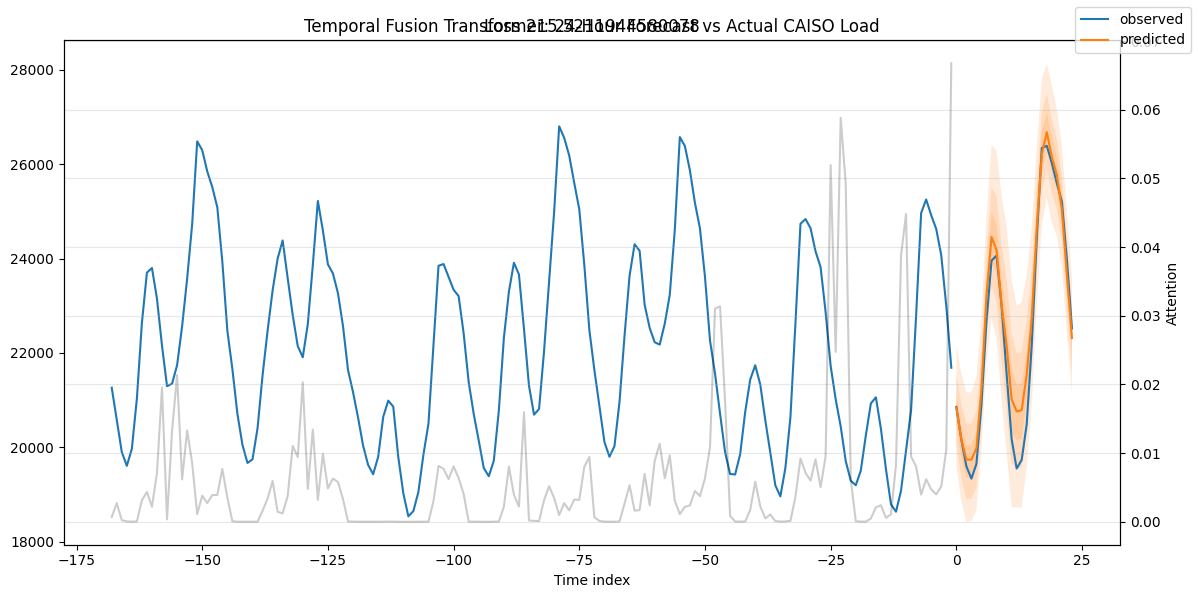

In [ ]:
import matplotlib.pyplot as plt
import torch
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer

# 1. Ask the active trainer for the exact path to the best model
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")

# 2. Load the model and move it to the CPU for plotting
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
best_tft = best_tft.to("cpu")
best_tft.eval()

# 3. Fetch a single batch of data from the validation set
x, y = next(iter(val_dataloader))

# 4. Generate predictions for this batch (disabling gradients for speed)
with torch.no_grad():
    out = best_tft(x)

# 5. Plot the results for the first time sequence (idx=0) in the batch
fig, ax = plt.subplots(figsize=(12, 6))
best_tft.plot_prediction(x, out, idx=0, add_loss_to_title=True, ax=ax)
plt.title("Temporal Fusion Transformer: 24-Hour Forecast vs Actual CAISO Load")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

print("Calculating metrics across the validation set. This may take a moment...")

# 1. Get the predictions directly from the model
predictions = best_tft.predict(val_dataloader)

# 2. Extract the actual true values manually from your dataloader
# val_dataloader yields (x, y) where y is a tuple: (true_values, weights)
actuals = torch.cat([y[0] for x, y in val_dataloader])

# 3. Calculate MAE and RMSE
mae = F.l1_loss(predictions, actuals)
rmse = torch.sqrt(F.mse_loss(predictions, actuals))

# 4. Print the final comparison
print("\n--- Final Performance Comparison ---")
print("Baseline XGBoost MAE:  787.15 MW")
print("Baseline XGBoost RMSE: 1155.26 MW")
print("-" * 36)
print(f"Deep Learning TFT MAE:  {mae.item():.2f} MW")
print(f"Deep Learning TFT RMSE: {rmse.item():.2f} MW")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Calculating metrics across the validation set. This may take a moment...

--- Final Performance Comparison ---
Baseline XGBoost MAE:  787.15 MW
Baseline XGBoost RMSE: 1155.26 MW
------------------------------------
Deep Learning TFT MAE:  392.42 MW
Deep Learning TFT RMSE: 517.87 MW


In [ ]:
from google.colab import drive
import shutil

# 1. Mount your Google Drive (a popup will ask for permission)
drive.mount('/content/drive')

# 2. Get the path to the model you just trained
best_model_path = trainer.checkpoint_callback.best_model_path

# 3. Choose a destination in your Google Drive
save_destination = '/content/drive/MyDrive/tft_caiso_model.ckpt'

# 4. Copy the file to safety
shutil.copy(best_model_path, save_destination)
print(f"Model successfully saved to: {save_destination}")

Mounted at /content/drive
Model successfully saved to: /content/drive/MyDrive/tft_caiso_model.ckpt
